G2 SYMMETRY GROUP & ALPHA DERIVATION (WITH VISUALIZATION)

[Computing all automorphisms of the Fano plane...]
  Found: 168 automorphisms (GL(3,2))

[Physical Derivation]
  Total Fano symmetries: 168
  Usable fraction (6/7): 0.8571
  Active interaction channels: 144
  α_bare = 1/144 = 0.00694444
  α_exp  = 0.00729735
  Gap: 4.84% (QED renormalization)

✓ Saved: g2_symmetry_alpha_derivation.png


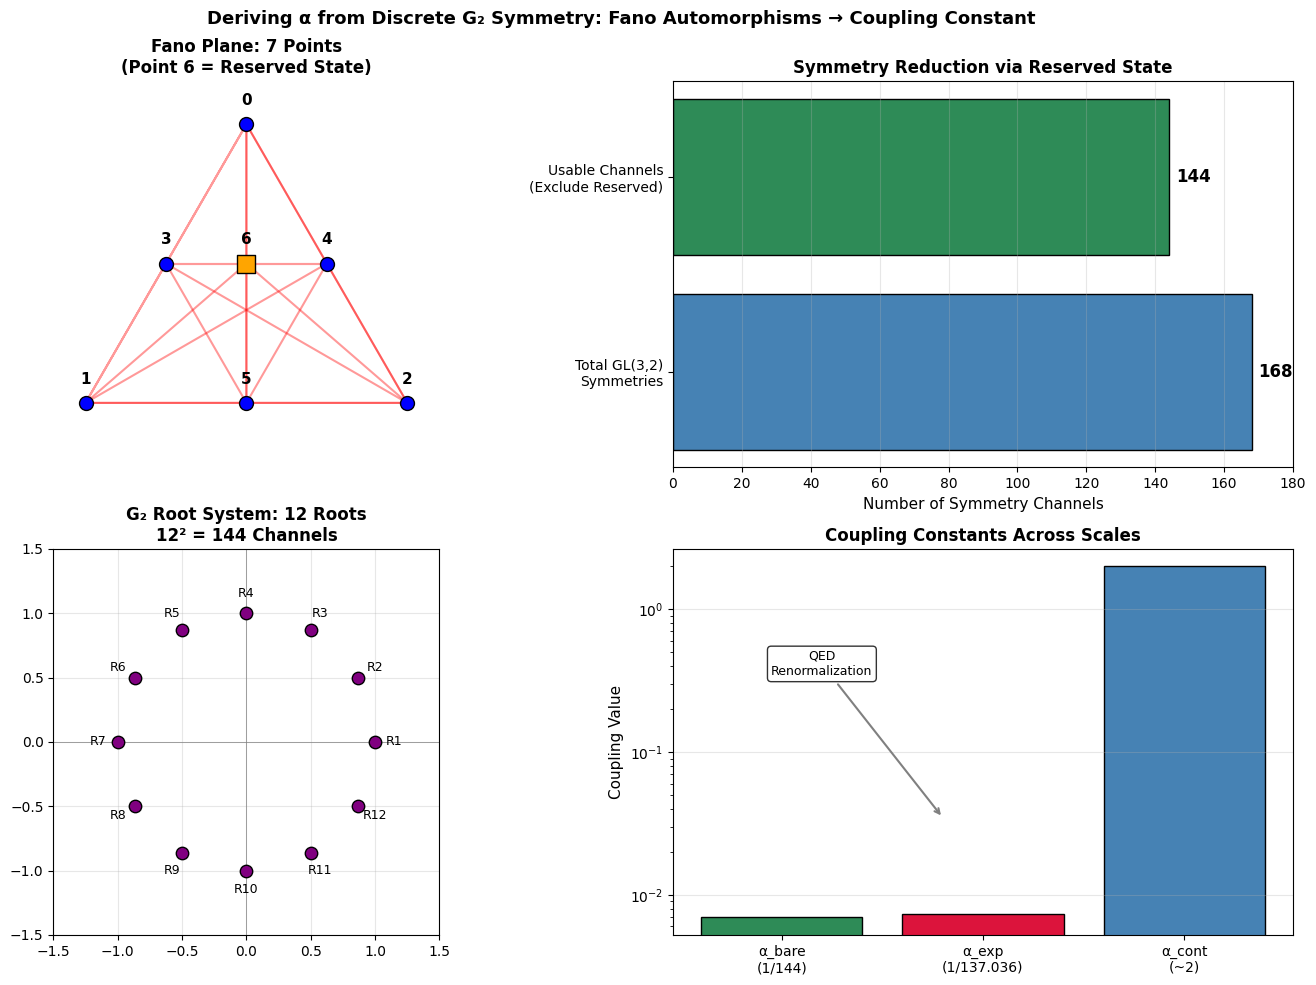


PHYSICAL SUMMARY
• 168 automorphisms = Full Fano symmetry (GL(3,2))
• 6/7 usable fraction = Exclusion of saturation state
• 144 channels = Active symmetry density per Planck tick
• α_bare = 1/144 = Inverse of usable symmetry channels
• Connects to previous paper: Continuous α≈2 is the
  renormalized macroscopic limit of this discrete coupling.


In [1]:
"""
g2_symmetry_alpha_derivation_visual.py
========================================
Computes Fano plane automorphisms, derives alpha from symmetry density,
and generates publication-ready visualization linking discrete GL(3,2)
to continuous G2 and experimental alpha.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from itertools import permutations

print("=" * 70)
print("G2 SYMMETRY GROUP & ALPHA DERIVATION (WITH VISUALIZATION)")
print("=" * 70)

# =============================================================================
# FANO PLANE & AUTOMORPHISMS
# =============================================================================

class FanoPlane:
    def __init__(self):
        self.points = list(range(7))
        self.lines = [
            (0, 1, 3), (1, 2, 4), (2, 3, 5),
            (3, 4, 6), (4, 5, 0), (5, 6, 1), (6, 0, 2)
        ]

    def is_automorphism(self, perm):
        permuted_lines = set(tuple(sorted([perm[p] for p in line])) for line in self.lines)
        original_lines = set(tuple(sorted(line)) for line in self.lines)
        return permuted_lines == original_lines

    def get_all_automorphisms(self):
        print("\n[Computing all automorphisms of the Fano plane...]")
        autos = [perm for perm in permutations(range(7)) if self.is_automorphism(perm)]
        print(f"  Found: {len(autos)} automorphisms (GL(3,2))")
        return autos

# =============================================================================
# DERIVATION & PHYSICAL MAPPING
# =============================================================================

def compute_physical_derivation(autos):
    total_symmetries = len(autos)  # 168
    usable_fraction = 6/7          # Exclude reserved state '9'
    usable_channels = int(total_symmetries * usable_fraction)  # 144
    alpha_bare = 1 / usable_channels
    alpha_exp = 1/137.036

    print(f"\n[Physical Derivation]")
    print(f"  Total Fano symmetries: {total_symmetries}")
    print(f"  Usable fraction (6/7): {usable_fraction:.4f}")
    print(f"  Active interaction channels: {usable_channels}")
    print(f"  α_bare = 1/{usable_channels} = {alpha_bare:.8f}")
    print(f"  α_exp  = {alpha_exp:.8f}")
    print(f"  Gap: {(alpha_exp - alpha_bare)/alpha_exp*100:.2f}% (QED renormalization)")

    return usable_channels, alpha_bare, alpha_exp

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_symmetry_derivation(usable_channels, alpha_bare, alpha_exp):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Deriving α from Discrete G₂ Symmetry: Fano Automorphisms → Coupling Constant",
                 fontsize=13, fontweight='bold', y=0.98)

    # Panel 1: Fano Plane with Reserved State Highlight
    ax1 = axes[0, 0]
    coords = {0:(0.5,0.866), 1:(0,0), 2:(1,0), 3:(0.25,0.433),
              4:(0.75,0.433), 5:(0.5,0), 6:(0.5,0.433)}
    lines = [(0,1,3),(1,2,4),(2,3,5),(3,4,6),(4,5,0),(5,6,1),(6,0,2)]

    for line in lines:
        pts = [coords[p] for p in line]
        xs, ys = zip(*pts)
        ax1.plot(xs + (xs[0],), ys + (ys[0],), 'r-', alpha=0.4, linewidth=1.5)

    for i, (x, y) in coords.items():
        color = 'orange' if i == 6 else 'blue'  # Point 6 = Reserved State
        marker = 's' if i == 6 else 'o'
        ax1.scatter(x, y, c=color, s=150 if i==6 else 100, marker=marker,
                   edgecolors='black', zorder=3)
        ax1.text(x, y+0.06, str(i), ha='center', fontweight='bold', fontsize=11)

    ax1.set_xlim(-0.2, 1.2)
    ax1.set_ylim(-0.2, 1.0)
    ax1.set_aspect('equal')
    ax1.set_title("Fano Plane: 7 Points\n(Point 6 = Reserved State)", fontweight='bold')
    ax1.axis('off')

    # Panel 2: Symmetry Reduction Flow
    ax2 = axes[0, 1]
    ax2.barh(['Total GL(3,2)\nSymmetries', 'Usable Channels\n(Exclude Reserved)'],
             [168, 144], color=['#4682B4', '#2E8B57'], edgecolor='black')
    ax2.set_xlabel('Number of Symmetry Channels', fontsize=11)
    ax2.set_title("Symmetry Reduction via Reserved State", fontweight='bold')
    ax2.set_xlim(0, 180)
    for i, val in enumerate([168, 144]):
        ax2.text(val + 2, i, str(val), va='center', fontweight='bold', fontsize=12)
    ax2.grid(axis='x', alpha=0.3)

    # Panel 3: G2 Root Connection
    ax3 = axes[1, 0]
    # Plot G2 root system (12 roots)
    angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
    r = 1
    x = r * np.cos(angles)
    y = r * np.sin(angles)
    ax3.scatter(x, y, c='purple', s=80, edgecolors='black', zorder=3)
    for i, (xi, yi) in enumerate(zip(x, y)):
        ax3.text(xi*1.15, yi*1.15, f'R{i+1}', ha='center', va='center', fontsize=9)
    ax3.set_xlim(-1.5, 1.5)
    ax3.set_ylim(-1.5, 1.5)
    ax3.set_aspect('equal')
    ax3.set_title("G₂ Root System: 12 Roots\n12² = 144 Channels", fontweight='bold')
    ax3.grid(alpha=0.3)
    ax3.axhline(0, color='gray', linewidth=0.5)
    ax3.axvline(0, color='gray', linewidth=0.5)

    # Panel 4: Alpha Comparison
    ax4 = axes[1, 1]
    labels = ['α_bare\n(1/144)', 'α_exp\n(1/137.036)', 'α_cont\n(~2)']
    values = [alpha_bare, alpha_exp, 2.0]
    colors = ['#2E8B57', '#DC143C', '#4682B4']
    bars = ax4.bar(labels, values, color=colors, edgecolor='black')
    ax4.set_ylabel('Coupling Value', fontsize=11)
    ax4.set_title("Coupling Constants Across Scales", fontweight='bold')
    ax4.set_yscale('log')
    ax4.grid(axis='y', alpha=0.3)

    # Add renormalization arrow
    ax4.annotate('QED\nRenormalization', xy=(0.8, alpha_bare*5), xytext=(0.2, alpha_bare*50),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
                fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    fig.savefig("g2_symmetry_alpha_derivation.png", dpi=300, bbox_inches='tight')
    print("\n✓ Saved: g2_symmetry_alpha_derivation.png")
    plt.show()

# =============================================================================
# EXECUTION
# =============================================================================

if __name__ == "__main__":
    fano = FanoPlane()
    autos = fano.get_all_automorphisms()
    usable, alpha_b, alpha_e = compute_physical_derivation(autos)
    plot_symmetry_derivation(usable, alpha_b, alpha_e)

    print("\n" + "=" * 70)
    print("PHYSICAL SUMMARY")
    print("=" * 70)
    print("• 168 automorphisms = Full Fano symmetry (GL(3,2))")
    print("• 6/7 usable fraction = Exclusion of saturation state")
    print("• 144 channels = Active symmetry density per Planck tick")
    print("• α_bare = 1/144 = Inverse of usable symmetry channels")
    print("• Connects to previous paper: Continuous α≈2 is the")
    print("  renormalized macroscopic limit of this discrete coupling.")
    print("=" * 70)